<a href="https://colab.research.google.com/github/KANGWEII/hands_on_ml/blob/feature-chapter_4/Chapter04/training_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Training Models

## Linear Regression

For a model with $n$ input features $x_1, x_2, \dots, x_n$:
$$
\hat{y} = 	\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n
$$
or, in vector form:
$$
\hat{y} = h_\theta(x) = \theta \cdot x
$$
where:
- $\hat{y}$ = predicted value
- $h_\theta$ = hypothesis function
- $\theta$ = parameter vector, contain the bias term (intercept) $\theta_0$ and feature weights $\theta_1, \theta_2, \cdots, \theta_n$
- $x$ = feature vector, $x_0, x_1, x_2, \cdots, x_n$, where $x_0$ is always equal to 1
- $\theta \cdot x$ = $\theta_0x_0 + \theta_1x_1 + \theta_2x_2 + \cdots + \theta_n x_n$

### The Normal Equation

$$
\hatθ = (X^TX)^{-1} X^T y
$$
where:
- $\hatθ$ = value of $θ$ that minimizes the cost function
- $y$ = vector of target values

Purpose:
- Find the parameter vector (the weights that the model learn) of a linear regression model that minimizes the cost function (MSE)
- The optimal parameter $\hatθ$:
  $$
  \mathbf{\hatθ} = \begin{pmatrix}
  \theta_0 \\
  \theta_1 \\
  \theta_2 \\
  \vdots \\
  \theta_n
  \end{pmatrix}
  $$

  - $\theta_0$ is the intercept
  - Slope coefficients $\theta_1, \theta_2, … , \theta_n$

In [1]:
import numpy as np

np.random.seed(42)
m = 100
X = 2 * np.random.rand(m,1)
y = 4 + 3 * X + np.random.randn(m,1)

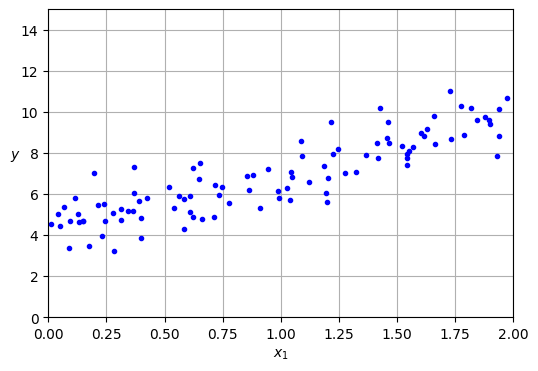

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

- Compute $\hatθ$ using normal equation

In [3]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# Intercept (bias) is 4.215
# Slope is 2.770
theta_best

array([[4.21509616],
       [2.77011339]])

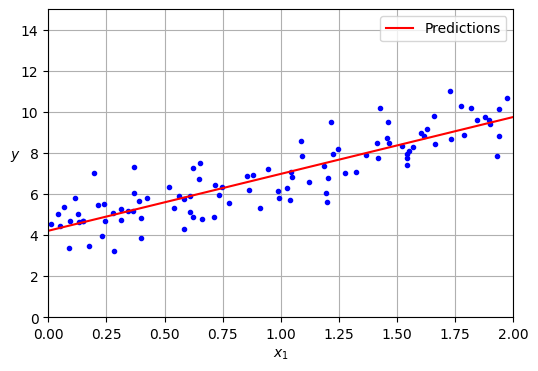

In [4]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend()
plt.show()

In [5]:
# All the background explanations above can be simplified by using Scikit-Learn linear regression

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [6]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

## Gradient Descent

- Generic optimization algorithm
- Tweak **parameters** iteratively to minimize cost function (MSE)
- Recommended Video: https://youtu.be/sDv4f4s2SB8?si=6H_AZ2aUpq1M1Lxl

1. Why is Mean Squared Error (MSE) cost function in paraboloid (bowl-shaped / U-shaped)?
   $$
   MSE = \frac{1}{m} \sum_{i=1}^{m} (Predicted_i - Actual_i)^2
   = \frac{1}{m} \sum_{i=1}^{m} (θ^Tx^{(i)} - y^{(i)})^2
   $$
   - It is a quadratic function of the model's parameters
   - Quadratic: something that relates to or is characterized by squares
   - Cost function graph of model with 1 parameter ($θ$) forms a simple parabola (2D U-shape)
   - Cost function graph of multiple parameters forms a multi-dimensional bowl shape

2. When will MSE cost function not form a paraboloid?
   - When using MSE to evaluate non-linear model
   - Data is insufficient or ill-conditioned

3. Is polynomial regression considered non-linear to form non-paraboloid plot?
   - Yes, however there is an important nuance in machine learning
   - Polynomial regression is considered linear regression model because it is linear in terms of the parameters ($θ$)
   - As long as the model is in the form of $\hat{y}= θ_0​f_0​(x) + θ_1​f_1​(x) + \cdots $ , where $f_i(x)$ can be any function of $x$ (like $x^2, sin⁡(x), log(x)$, the model is linear regression, because it’s linear in $θ$.

### Batch Gradient Descent

In [7]:
eta = 0.1 # Learning Rate
n_epochs = 1000
m = len(X_b)  # Number of instances

np.random.seed(42)
theta = np.random.randn(2,1)  # Randomly initialized model parameters

for epoch in range(n_epochs):
  gradients = 2 / m * X_b.T @ (X_b @ theta - y)
  theta = theta - eta * gradients

theta

array([[4.21509616],
       [2.77011339]])

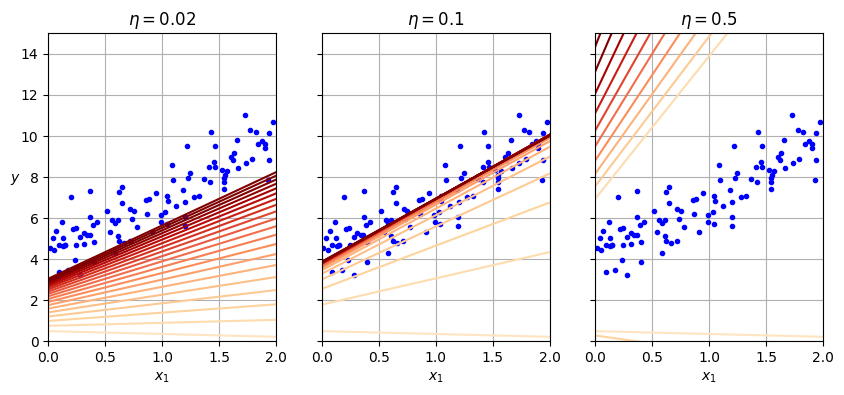

In [8]:
# Plot the first 20 steps of gradient descent using different learning rates

import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # Random initialization

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
plt.show()

### Stochastic Gradient Descent

What is the difference between batch gradient descent and stochastic gradient descent?
- batch gradient descent (BGD) uses the whole training set to compute the gradients at every step
- stochastic gradient descent (SGD) picks a random instance in the training set at every step and computes the gradients based only on that single instance
- SGD cost function is very irregular, has a better chance of finding the global minimum than BGD
- SGD randomness can help to escape from local optima but it can never settle at the minimum

Solution to SGD dilemma
- gradually reduce the learning rate (*learning schedule*)

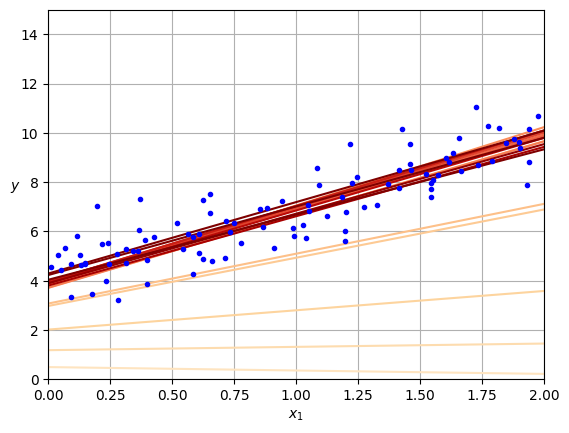

array([[4.21076011],
       [2.74856079]])

In [10]:
# Implement SGD with simple learning schedule

n_epochs = 50
t0, t1 = 5, 50  # Learning schedule hyperparameters
theta_path_sgd = []
n_shown = 20

def learning_schedule(t):
  return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2,1)  # Random initialization

for epoch in range(n_epochs):
  for iteration in range(m):

    if epoch == 0 and iteration < n_shown:
      y_predict = X_new_b @ theta
      color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
      plt.plot(X_new, y_predict, color=color)

    random_index = np.random.randint(m)
    xi = X_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2 * xi.T @ (xi @ theta - yi)
    eta = learning_schedule(epoch * m + iteration)
    theta = theta - eta * gradients
    theta_path_sgd.append(theta)

plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

theta

- The figure shows the first 20 steps of training and how irregular the steps are

In [13]:
# Scikit-Learn SGDRegressor class, defaults to optimizing the MSE cost function

from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets

sgd_reg.intercept_, sgd_reg.coef_

(array([4.15474433]), array([2.82564538]))